# pocketHb 01 — bootstrap

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthvee/pocketHb/blob/main/notebooks/01_bootstrap.ipynb)

download the [nature sci data 2024 fingernail+hb dataset](https://www.nature.com/articles/s41597-024-03895-9), inspect schema, visualize hb distribution and one sample image with its labeled nail/skin bboxes.

this is the base dataset used to train the photo→hb regressor. personalization comes later, on the user's own iphone captures, since this dataset has only 1 image per subject.

In [1]:
# normalize cwd to repo root, then colab-clone if needed
import os, sys, subprocess
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

if not Path('scripts/download_data.py').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/jayanthvee/pocketHb.git'])
    os.chdir('pocketHb')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'])

print('cwd:', Path.cwd())

cwd: C:\Users\vasup\pocketHb


In [2]:
# download + extract dataset if not already present
subprocess.check_call([sys.executable, 'scripts/download_data.py'])

0

## schema

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import ast

META = Path('data/extracted/metadata.csv')
PHOTOS = Path('data/extracted/photo')

df = pd.read_csv(META)
df['hb_g_per_dL'] = df['HB_LEVEL_GperL'] / 10.0
df['nail_bboxes'] = df['NAIL_BOUNDING_BOXES'].apply(ast.literal_eval)
df['skin_bboxes'] = df['SKIN_BOUNDING_BOXES'].apply(ast.literal_eval)

print(f'rows: {len(df)}')
print(f'unique patients: {df["PATIENT_ID"].nunique()}')
print(f'unique session-date hashes: {df["MEASUREMENT_DATE"].nunique()}')
print(f'images in photo/: {len(list(PHOTOS.glob("*.jpg")))}')
df.head()

rows: 250
unique patients: 250
unique session-date hashes: 20
images in photo/: 251


,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES,hb_g_per_dL,nail_bboxes,skin_bboxes
0,1,14b0293a34344cc4fba0fa39d5370c52,134.0,"[[251, 447, 302, 505], [123, 429, 183, 483], [...","[[267, 586, 324, 627], [148, 556, 200, 614], [...",13.4,"[[251, 447, 302, 505], [123, 429, 183, 483], [...","[[267, 586, 324, 627], [148, 556, 200, 614], [..."
1,2,14b0293a34344cc4fba0fa39d5370c52,108.0,"[[236, 503, 281, 556], [148, 457, 195, 514], [...","[[252, 612, 294, 647], [162, 585, 212, 632], [...",10.8,"[[236, 503, 281, 556], [148, 457, 195, 514], [...","[[252, 612, 294, 647], [162, 585, 212, 632], [..."
2,5,14b0293a34344cc4fba0fa39d5370c52,84.0,"[[244, 508, 277, 562], [183, 448, 220, 505], [...","[[264, 629, 303, 662], [193, 584, 232, 619], [...",8.4,"[[244, 508, 277, 562], [183, 448, 220, 505], [...","[[264, 629, 303, 662], [193, 584, 232, 619], [..."
3,6,14b0293a34344cc4fba0fa39d5370c52,138.0,"[[311, 456, 363, 521], [182, 408, 237, 471], [...","[[318, 609, 380, 650], [189, 562, 245, 616], [...",13.8,"[[311, 456, 363, 521], [182, 408, 237, 471], [...","[[318, 609, 380, 650], [189, 562, 245, 616], [..."
4,7,14b0293a34344cc4fba0fa39d5370c52,119.0,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20...",11.9,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20..."


## hb distribution

WHO anemia cutoffs: men <13 g/dL, non-pregnant women <12 g/dL. dataset is heavily weighted toward the anemic side, which is good — the model sees the full clinical range.

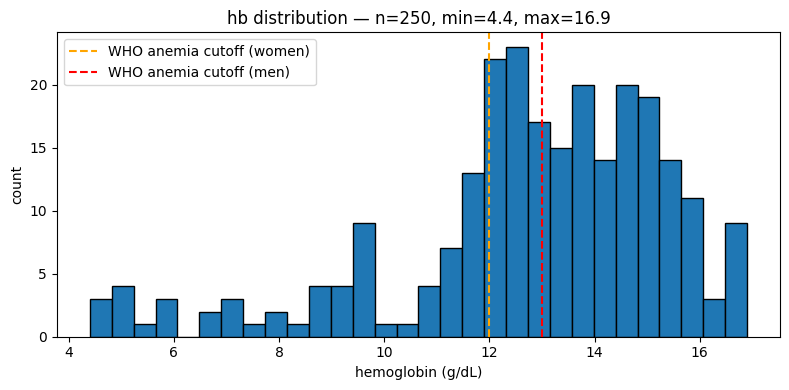

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['hb_g_per_dL'], bins=30, edgecolor='black')
ax.axvline(12.0, color='orange', ls='--', label='WHO anemia cutoff (women)')
ax.axvline(13.0, color='red', ls='--', label='WHO anemia cutoff (men)')
ax.set_xlabel('hemoglobin (g/dL)')
ax.set_ylabel('count')
ax.set_title(f'hb distribution — n={len(df)}, min={df["hb_g_per_dL"].min():.1f}, max={df["hb_g_per_dL"].max():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## sample image with labeled bboxes

each photo shows 3 fingers. the dataset labels 3 nail bboxes + 3 skin bboxes per image.

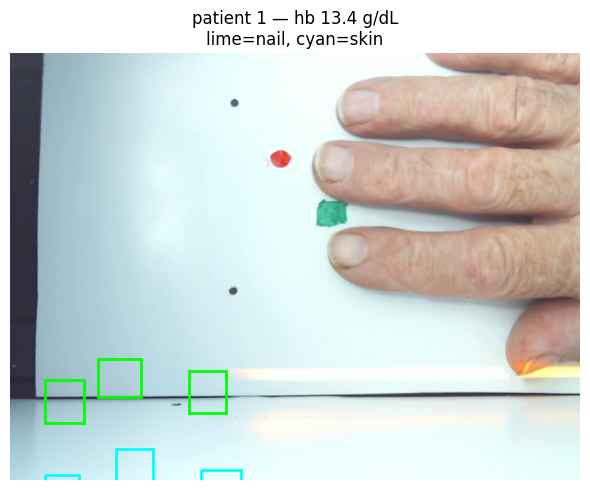

In [5]:
from matplotlib.patches import Rectangle

row = df.iloc[0]
img_path = PHOTOS / f'{row["PATIENT_ID"]}.jpg'
img = Image.open(img_path)

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img)
for x1, y1, x2, y2 in row['nail_bboxes']:
    ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='lime', lw=2))
for x1, y1, x2, y2 in row['skin_bboxes']:
    ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='cyan', lw=2))
ax.set_title(f'patient {row["PATIENT_ID"]} — hb {row["hb_g_per_dL"]:.1f} g/dL\nlime=nail, cyan=skin')
ax.axis('off')
plt.tight_layout()
plt.show()

## takeaways

- 250 subjects, 1 image per subject, hb range 4.4–16.9 g/dL
- bboxes are pre-labeled — no need to train a nail-segmentation model
- 3 nail crops + 3 skin crops per image → ~750 nail patches total for training
- personalization is impossible from this dataset alone (no repeat measurements per subject) — it will come from the user's own iphone captures against their known baseline hb